In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [47]:
df = pd.read_csv("ferry_passengers.csv")

In [48]:
df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [49]:
df = df.rename(columns={"#Passengers": "Passengers"})

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Month       144 non-null    object
 1   Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [51]:
df.isna().sum()

Month         0
Passengers    0
dtype: int64

In [ ]:
# Spalte "Month" in pandas-lesbares Format für Daten umwandeln

df["Month"] = pd.to_datetime(df["Month"], errors="coerce")

# Month als Index setzen, da zeitliche Reihenfolge essentiell
# Im klassichen ML ist jede Zeile eine unabhängige Beobachtung, aber bei Time Series sind sie zeitlich abhängig
# Time Series: Zeit beschreibt Struktur der Daten, nicht deren Inhalt, daher als Index und nicht im Feature-Raum

df = df.set_index("Month")
df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [53]:
# Prüfen, ob beim Parsen der Spalte "Month" etwas schiefgelaufen ist

df.index.isna().sum()

np.int64(0)

In [54]:
# Frequenzcode für Pandas ("MS" = Month Start) setzen
# Pandas konstruiert die Daten intern als Zeitachse
# Zuvor sieht Pandas zwar Datumswerte, aber erkennt diese nicht als feste Zeitreihe
# Explizite Frequenz ist Vorraussetzung bzw. starke Hilfe für spätere Arbeit mit den Daten

df = df.asfreq("MS")

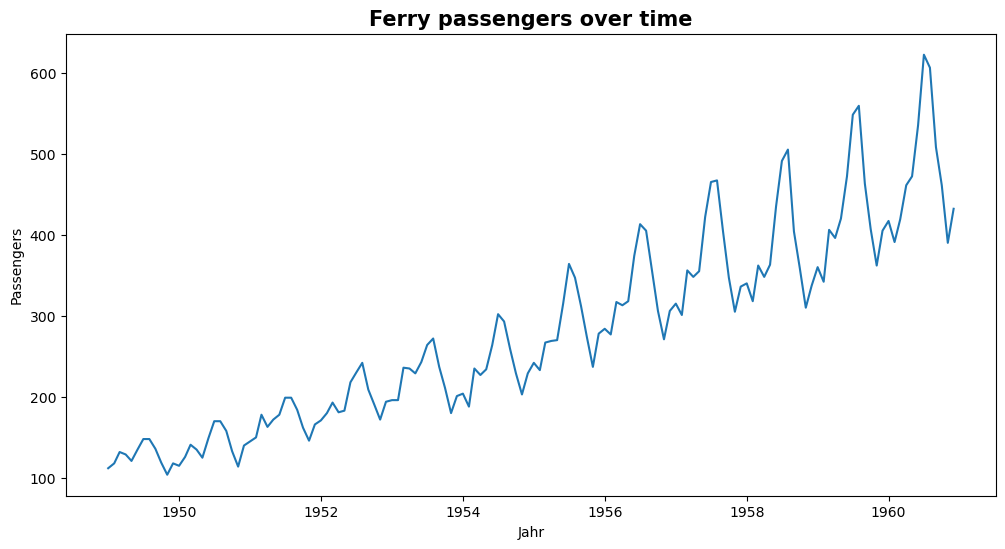

In [55]:
plt.figure(figsize=(12, 6))
plt.plot(df["Passengers"])
plt.title("Ferry passengers over time", fontsize=15, fontweight="bold")
plt.xlabel("Jahr")
plt.ylabel("Passengers")
plt.show()

In [56]:
from statsmodels.tsa.seasonal import seasonal_decompose

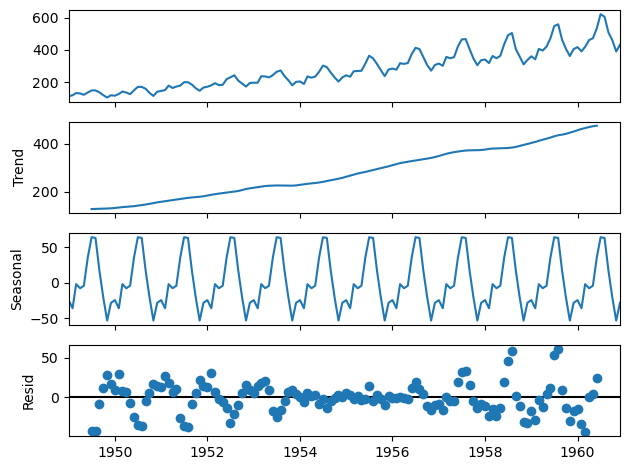

In [57]:
decomposition = seasonal_decompose(df)
decomposition.plot();

In [58]:
# Trend: Anstieg der Passagierzahlen über Zeit
# Seasonal: Zeigt, dass sich Datenstruktur jährlich wiederholt --> eine Saison ist 12 Monate lang
# Resid: Alles, was nicht durch Trend oder Saisonalität erkläret werden kann,
#        hat leichte Saisonalität und schwankt zwischen +-50 Passagieren
#    --> schlecht: man will keine Saisonalität

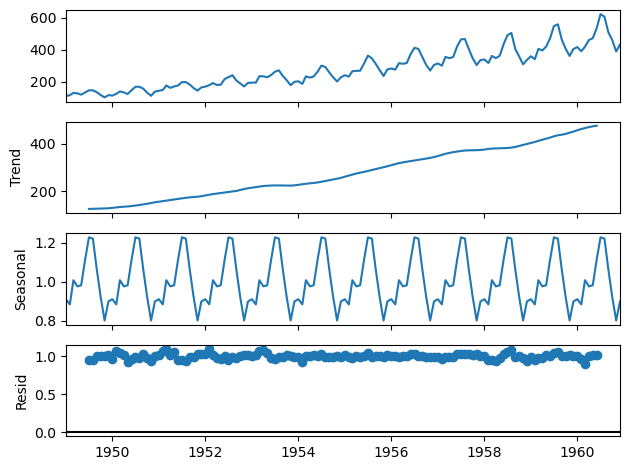

In [59]:
# Decomposition erneut durchführen, aber dieses Mal mit multiplikativem Modell (Standard: additativ)

decomp_add = seasonal_decompose(df, model="multiplicative", period=12)
decomp_add.plot();

In [60]:
# Residuen liegen nahe an einer Linie --> Trend und Saisonalität erklären fast gesamte Struktur

In [61]:
# Log-Transformation wegen zuvor beobachtetem multiplikativem Verhalten --> wachsende Varianz über Zeit

df["log_passengers"] = np.log(df["Passengers"])

# Seasonal Differencing mit Periode 12 durchführen, da Logging den Trend nicht vollständig entfernt

df["log_diff_seasonal"] = df["log_passengers"].diff(12)

# Differencing für Entfernen des Trends hinzufügen

df["log_diff_1_seasonal"] = df["log_diff_seasonal"].diff()

# NaN Werte entfernen, da für jede Zeit ein Vorgängerwert berechnet wird --> für ersten Zeitpunkt wird NaN gesetzt

log_diff_1 = df["log_diff_1_seasonal"].dropna()

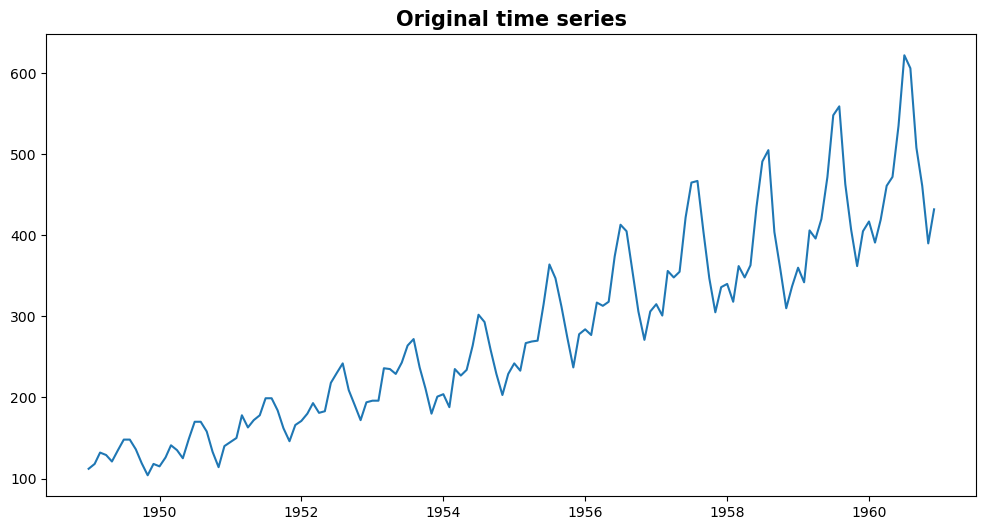

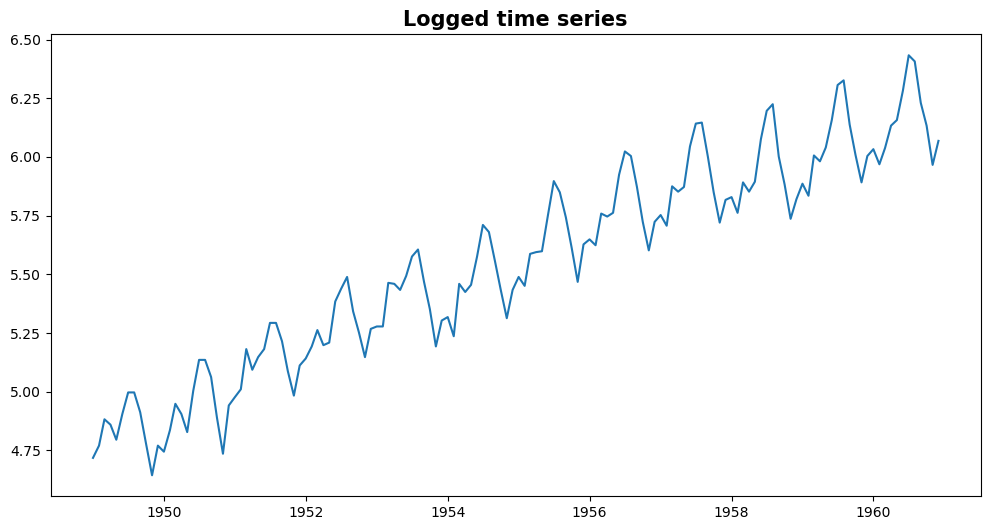

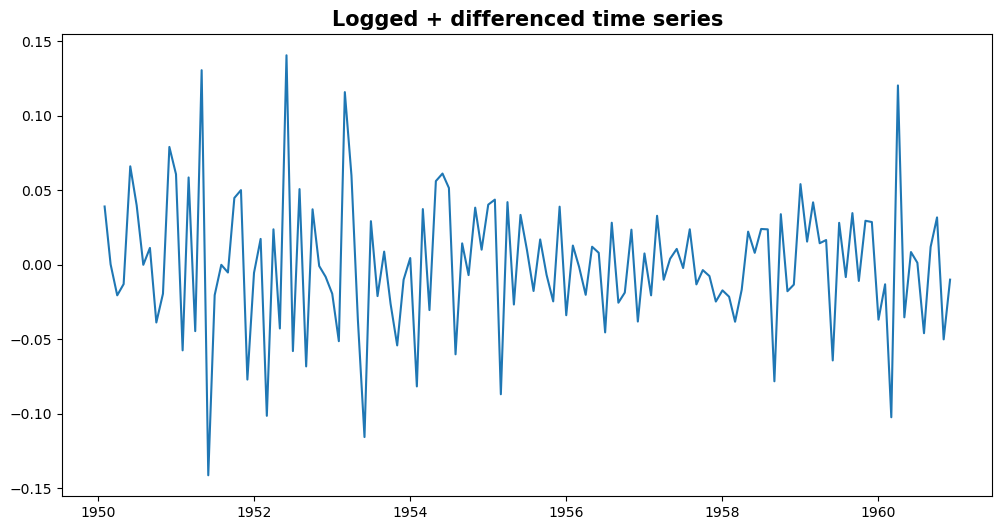

In [62]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["Passengers"])
plt.title("Original time series", fontsize=15, fontweight="bold")
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(df.index, df["log_passengers"])
plt.title("Logged time series", fontsize=15, fontweight="bold")
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(log_diff_1.index, log_diff_1)
plt.title("Logged + differenced time series", fontsize=15, fontweight="bold")
plt.show()

In [63]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

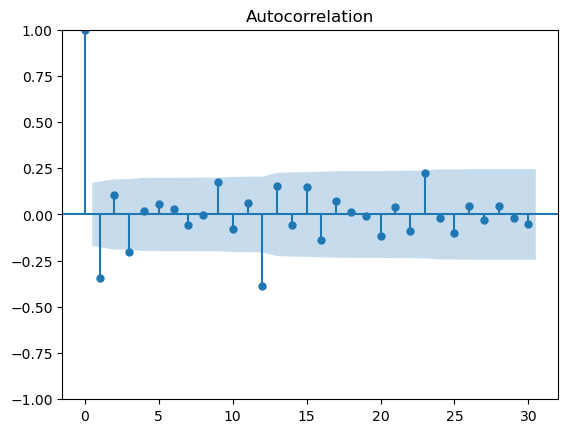

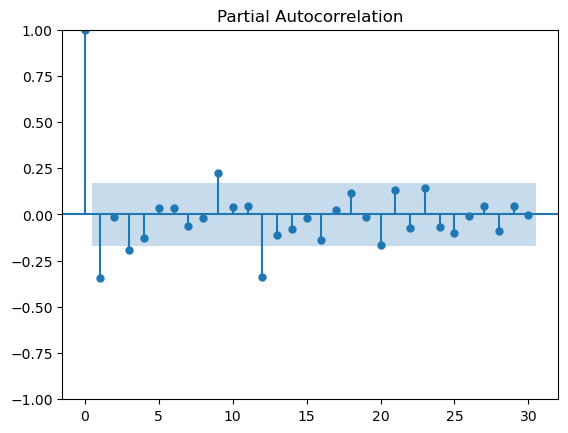

In [64]:
plot_acf(log_diff_1, lags=30)
plot_pacf(log_diff_1, lags=30)
plt.show()

In [65]:
# Nach Transformation zeigen ACF und PACF keine klaren Strukturen oder signifikanten Peaks. (außer bei lag 0, aber dies zeigt Korrelation der Zeitreihe mit sich selbst)
# Dies deutet darauf hin, dass Trend und Seasonalität erfolgreich entfernt wurden und nur noch white noise übberbleibt
# --> SARIMA-Modell mit niedriger Ordnung reicht aus

In [66]:
# Train-Test-Split erstellen
# Zielvariable definieren (log-transformiert, um Varianz stabil zu halten) (differencing wird von Modell selbst durchgeführt)

y = df["log_passengers"]

# Zeitbasierter Split
# Train-Split --> Vergangenheit

train = y.loc[: "1958-12-01"]

# Test-Split --> Zukunft

test = y.loc["1959-01-01":]

In [67]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [80]:
# Sarima Modell definieren

sarima = SARIMAX(train, order=(0,1,1), seasonal_order=(0, 1, 1, 12))

# fit anwenden, um Parameter des Modells mit Maximum-Likelihood-Schätzung der Trainingsdaten zu bestimmen
# --> wandelt oben definiertes Modell in konkretes, geschätztes und trainiertes Modell um

sarima_fit = sarima.fit()
print(sarima_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                     log_passengers   No. Observations:                  120
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                 197.505
Date:                            Wed, 07 Jan 2026   AIC                           -389.010
Time:                                    16:20:38   BIC                           -380.991
Sample:                                01-01-1949   HQIC                          -385.759
                                     - 12-01-1958                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3425      0.087     -3.923      0.000      -0.514      -0.171
ma.S.L12      -0.5406      0.105   

In [69]:
# P>|z] muss <0,05 sein, um Signifikanz sicherzustellen

# AR-Werte verwerfen (erster Parameter von order=0), da sie nicht signifikant sind
# --> Werte tragen statistich nichts bei, aber erhöhen Varianz und Modellkomplexität

In [70]:
# ma.L1
# Kurzfristiger Moving-Average-Term mit Lag 1
# Vorhersagefehler aus Vormonat wirken sich auf aktuellen Monat aus

# ma.S.L12
# Saisonaler Moving-Average-Term mit Lag 12
# Fehler aus gleichen Monat des Vorjahres beeinflussen aktuellen Wert

# sigma2
# Varianz der Residuen
# Geringer Wert deutet auf gute Anpassung des Modells an Daten hin

In [71]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [72]:
# Walk-Forward Validation für SARIMA Modell
def walk_forward_validation_sarima(train, test, order, seasonal_order):
    """
    Walk-Forward Validation für SARIMA Modell
    """
    predictions = []
    history = list(train)
    
    for t in range(len(test)):
        # SARIMA Modell trainieren
        model = SARIMAX(history, order=order, seasonal_order=seasonal_order)
        model_fit = model.fit(disp=False)
        
        # Ein-Schritt-Vorhersage
        yhat = model_fit.forecast(steps=1)[0]
        predictions.append(yhat)
        
        # Wahren Wert zur Historie hinzufügen
        obs = test.iloc[t]
        history.append(obs)
        
        if (t+1) % 10 == 0:
            print(f'Schritt {t+1}/{len(test)} abgeschlossen')
    
    return np.array(predictions)

sarima_predictions_log = walk_forward_validation_sarima(train, test, order=(0,1,1), seasonal_order=(0,1,1,12))
final_predictions = np.exp(sarima_predictions_log)
original_test = np.exp(test)
original_train = np.exp(train)

Schritt 10/24 abgeschlossen
Schritt 20/24 abgeschlossen


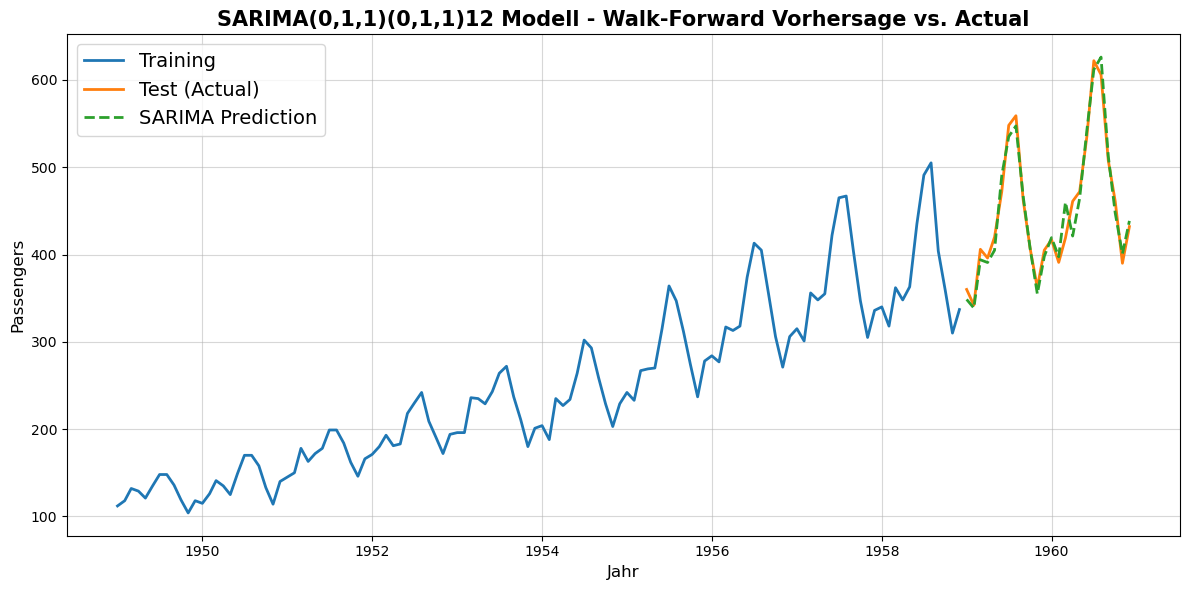

In [73]:
# Visualisierung
plt.figure(figsize=(12, 6))
plt.plot(train.index, original_train, label="Training", linewidth=2)
plt.plot(test.index, original_test, label="Test (Actual)", linewidth=2)
plt.plot(test.index, final_predictions, label="SARIMA Prediction", linewidth=2, linestyle="--")
plt.title("SARIMA(0,1,1)(0,1,1)12 Modell - Walk-Forward Vorhersage vs. Actual", fontsize=15, fontweight="bold")
plt.xlabel("Jahr", fontsize=12)
plt.ylabel("Passengers", fontsize=12)
plt.legend(fontsize=14)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

In [74]:
from scipy import stats

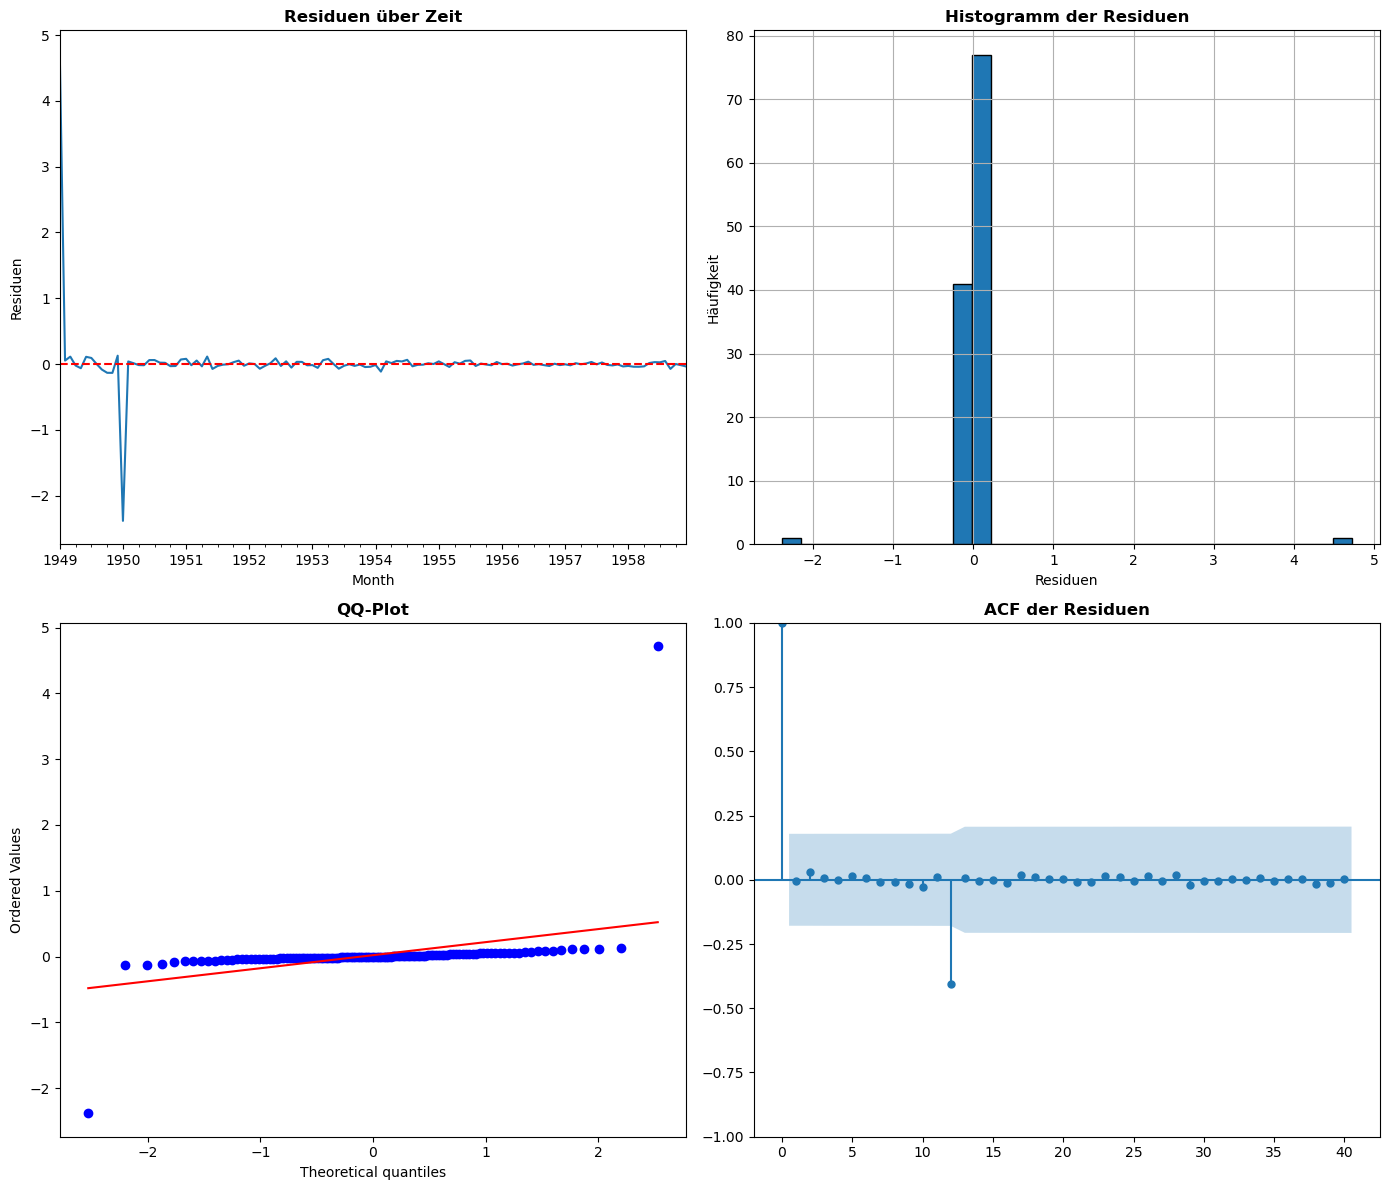

In [75]:
residuals = sarima_fit.resid
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Residuen über Zeit
residuals.plot(ax=axes[0,0])
axes[0,0].set_title("Residuen über Zeit", fontweight="bold")
axes[0,0].set_ylabel("Residuen")
axes[0,0].axhline(y=0, color="r", linestyle="--")

# Histogramm der Residuen
residuals.hist(ax=axes[0,1], bins=30, edgecolor="black")
axes[0,1].set_title("Histogramm der Residuen", fontweight="bold")
axes[0,1].set_xlabel("Residuen")
axes[0,1].set_ylabel("Häufigkeit")

# QQ-Plot
stats.probplot(residuals, dist="norm", plot=axes[1,0])
axes[1,0].set_title("QQ-Plot", fontweight="bold")

# ACF der Residuen
plot_acf(residuals, lags=40, ax=axes[1,1])
axes[1,1].set_title("ACF der Residuen", fontweight="bold")

plt.tight_layout()
plt.show()

In [76]:
# Residuen schwanken um 0 herum --> gut
# Residuen sind annähernd normalverteilt --> gut
# Punkte liegen nahe an Diagonale des QQ-Plots --> gut
# Keine signifikanten Korrelationen bei ACF --> gut